<a href="https://colab.research.google.com/github/Maanvijangir/Lung-Cancer-Predictive-System/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

Load Dataset

In [ ]:
lung_data = pd.read_csv("/content/drive/MyDrive/survey_lung_cancer.csv")

EDA

In [ ]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,MALE,69,0,1,1,0,0,1,0,1,1,1,1,1,1,YES
1,MALE,74,1,0,0,0,1,1,1,0,0,0,1,1,1,YES
2,FEMALE,59,0,0,0,1,0,1,0,1,0,1,1,0,1,NO
3,MALE,63,1,1,1,0,0,0,0,0,1,0,0,1,1,NO
4,FEMALE,63,0,1,0,0,0,0,0,1,0,1,1,0,0,NO


In [ ]:
print(lung_data.info)

<bound method DataFrame.info of      GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      MALE   69        0               1        1              0   
1      MALE   74        1               0        0              0   
2    FEMALE   59        0               0        0              1   
3      MALE   63        1               1        1              0   
4    FEMALE   63        0               1        0              0   
..      ...  ...      ...             ...      ...            ...   
304  FEMALE   56        0               0        0              1   
305    MALE   70        1               0        0              0   
306    MALE   58        1               0        0              0   
307    MALE   67        1               0        1              0   
308    MALE   62        0               0        0              1   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  0         1         0         1                

In [ ]:
lung_data.shape

(309, 16)

Missing values

In [ ]:
print(lung_data.isnull().sum())

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [ ]:
print(lung_data["GENDER"].unique())
print(lung_data["LUNG_CANCER"].unique())


['MALE' 'FEMALE']
['YES' 'NO']


In [ ]:
#Convert 'Gender' (M->0, F->1) and 'Lung_cancer' (Yes->1, No->0)
lung_data["GENDER"] = lung_data["GENDER"].map({"MALE":0, "FEMALE":1})
lung_data["LUNG_CANCER"] = lung_data["LUNG_CANCER"].map({"YES":1, "NO":0})
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [ ]:
#Dependent Variable
x = lung_data.iloc[:,0:-1]
x

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,1,56,0,0,0,1,1,1,0,0,1,1,1,1,0
305,0,70,1,0,0,0,0,1,1,1,1,1,1,0,1
306,0,58,1,0,0,0,0,0,1,1,1,1,0,0,1
307,0,67,1,0,1,0,0,1,1,0,1,1,1,0,1


In [ ]:
#Independent Variable
y = lung_data["LUNG_CANCER"]
y = y.values.ravel()
y

array([1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
#Splitting data
dependent_var = lung_data.iloc[:, :-1] #Features
independent_var = lung_data.iloc[:, -1] #Target
x_train, x_test, y_train, y_test = train_test_split(dependent_var, independent_var, test_size=1/3,random_state=0)

In [ ]:
#Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(x_train, y_train)

prediction1 = log_reg.predict(x_test)
prediction1


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction1[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=Cancer
Order 5: Actual=Cancer, Predicted=Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
knn.fit(x_train, y_train)

prediction2 = knn.predict(x_test)
prediction2

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction2[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=Cancer
Order 5: Actual=Cancer, Predicted=Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#Decision Tree
tree = DecisionTreeClassifier(random_state=0, criterion="entropy")
tree.fit(x_train, y_train)

prediction3 = tree.predict(x_test)
prediction3

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction3[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=No Cancer
Order 5: Actual=Cancer, Predicted=Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#SVM CLassifier
svm = OneVsRestClassifier(BaggingClassifier(SVC(C=10, kernel='rbf', random_state=9, probability=True), n_jobs=-1))
svm.fit(x_train, y_train)

prediction4 = svm.predict(x_test)
prediction4

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction4[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=Cancer
Order 5: Actual=Cancer, Predicted=Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#Naive Bayes
nb = GaussianNB()
nb.fit(x_train, y_train)

prediction5 = nb.predict(x_test)
prediction5

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction5[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=Cancer
Order 5: Actual=Cancer, Predicted=No Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(x_train, y_train)

prediction6 = rf_classifier.predict(x_test)
prediction6

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
for i in range(10):
  actual = "Cancer" if y_test.iloc[i] == 1 else "No Cancer"
  predicted = "Cancer" if prediction6[i] == 1 else "No Cancer"
  print(f"Order {i+1}: Actual={actual}, Predicted={predicted}")

Order 1: Actual=Cancer, Predicted=Cancer
Order 2: Actual=Cancer, Predicted=Cancer
Order 3: Actual=Cancer, Predicted=Cancer
Order 4: Actual=No Cancer, Predicted=Cancer
Order 5: Actual=Cancer, Predicted=Cancer
Order 6: Actual=Cancer, Predicted=Cancer
Order 7: Actual=Cancer, Predicted=Cancer
Order 8: Actual=Cancer, Predicted=Cancer
Order 9: Actual=Cancer, Predicted=Cancer
Order 10: Actual=Cancer, Predicted=Cancer


In [ ]:
#Evaluation Function
def evaluate_model(y_true, y_pred, model_name, results_dict):
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)

  #store result in dictionary
  results_dict[model_name] = accuracy

  print(f"{model_name} Metrics:")
  print(f"Accuracy : {accuracy:.4f}")
  print(f"Precision : {precision:.4f}")
  print(f"Recall : {recall:.4f}")
  print(f"F1 Score : {f1:.4f}\n")

In [ ]:
#Dictionary to store accuracy results
accuracy_results = {}

#Evaluate each model
evaluate_model(y_test, prediction1, "Logistic Regression",accuracy_results)
evaluate_model(y_test, prediction2, "KNN",accuracy_results)
evaluate_model(y_test, prediction3, "Decision tree",accuracy_results)
evaluate_model(y_test, prediction4, "SVM",accuracy_results)
evaluate_model(y_test, prediction5, "Naive Bayes",accuracy_results)
evaluate_model(y_test, prediction6, "Random Forest",accuracy_results)

Logistic Regression Metrics:
Accuracy : 0.9029
Precision : 0.9140
Recall : 0.9770
F1 Score : 0.9444

KNN Metrics:
Accuracy : 0.8447
Precision : 0.8586
Recall : 0.9770
F1 Score : 0.9140

Decision tree Metrics:
Accuracy : 0.8641
Precision : 0.9195
Recall : 0.9195
F1 Score : 0.9195

SVM Metrics:
Accuracy : 0.8447
Precision : 0.8447
Recall : 1.0000
F1 Score : 0.9158

Naive Bayes Metrics:
Accuracy : 0.8641
Precision : 0.9101
Recall : 0.9310
F1 Score : 0.9205

Random Forest Metrics:
Accuracy : 0.8932
Precision : 0.9043
Recall : 0.9770
F1 Score : 0.9392



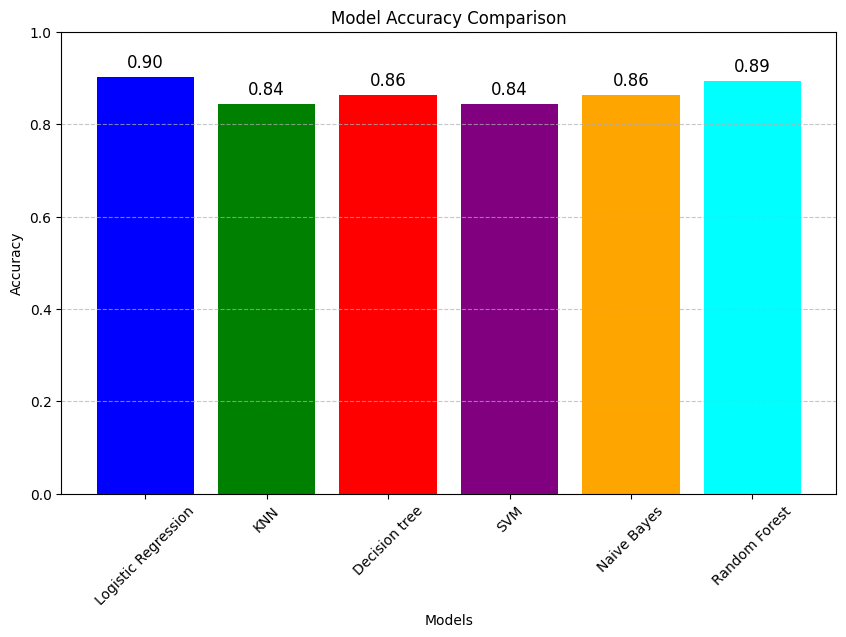

In [ ]:
#Plot Accuracy of all models
plt.figure(figsize=(10,6))
plt.bar(accuracy_results.keys(), accuracy_results.values(), color=['blue','green','red','purple','orange','cyan'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--', alpha=0.7)

#show accuracy values on top of bars
for i, (model, acc) in enumerate(accuracy_results.items()):
  plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

plt.show()

In [ ]:
#Confusion Matrix Plotting
def plot_confusion_matrix(y_true, y_pred, model_name):
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title(f"{model_name} - Confusion Matrix")
  plt.show()

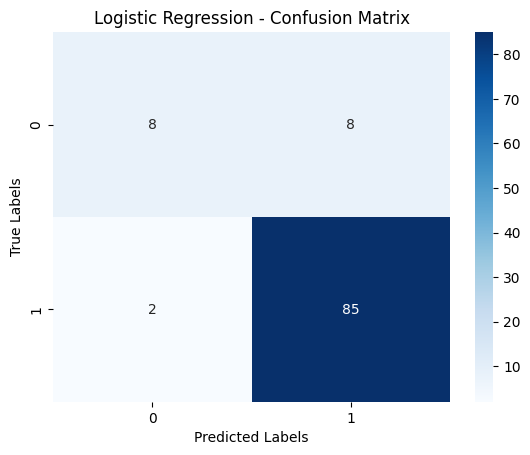

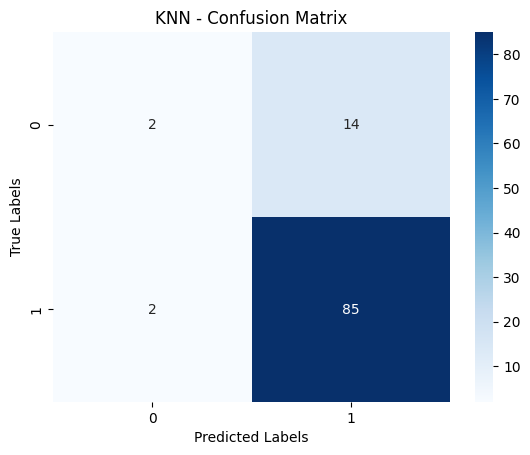

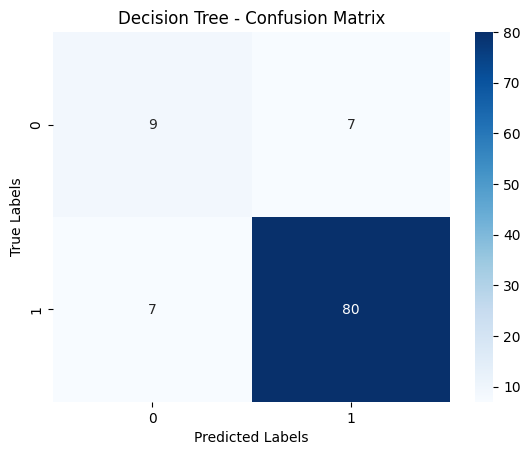

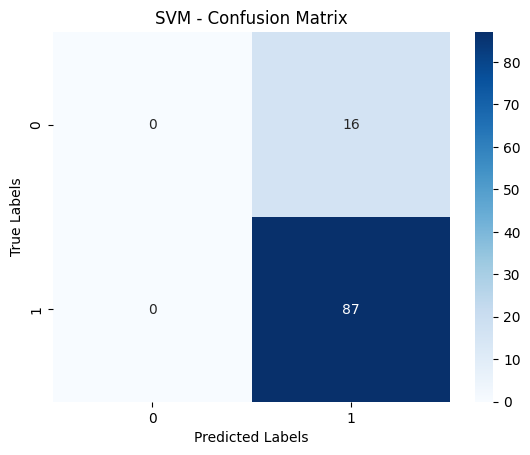

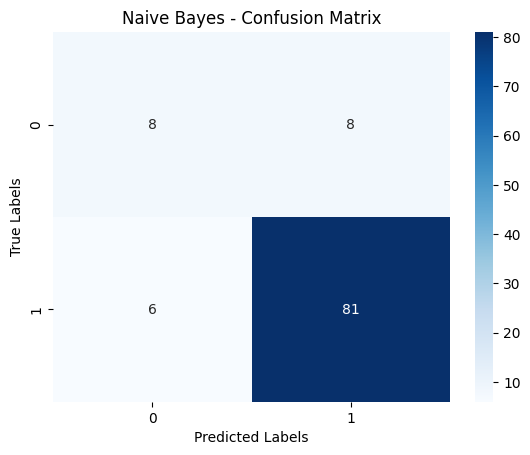

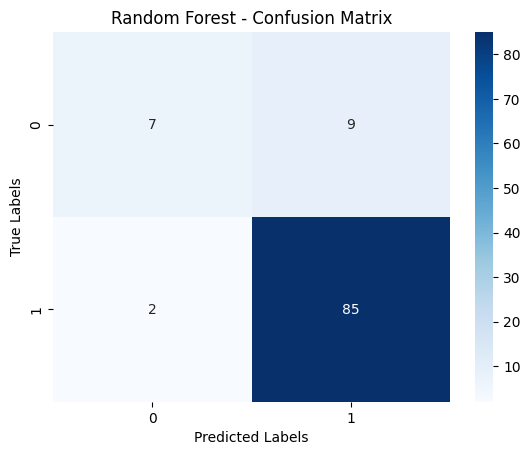

In [ ]:
plot_confusion_matrix(y_test, prediction1, "Logistic Regression")
plot_confusion_matrix(y_test, prediction2, "KNN")
plot_confusion_matrix(y_test, prediction3, "Decision Tree")
plot_confusion_matrix(y_test, prediction4, "SVM")
plot_confusion_matrix(y_test, prediction5, "Naive Bayes")
plot_confusion_matrix(y_test, prediction6, "Random Forest")

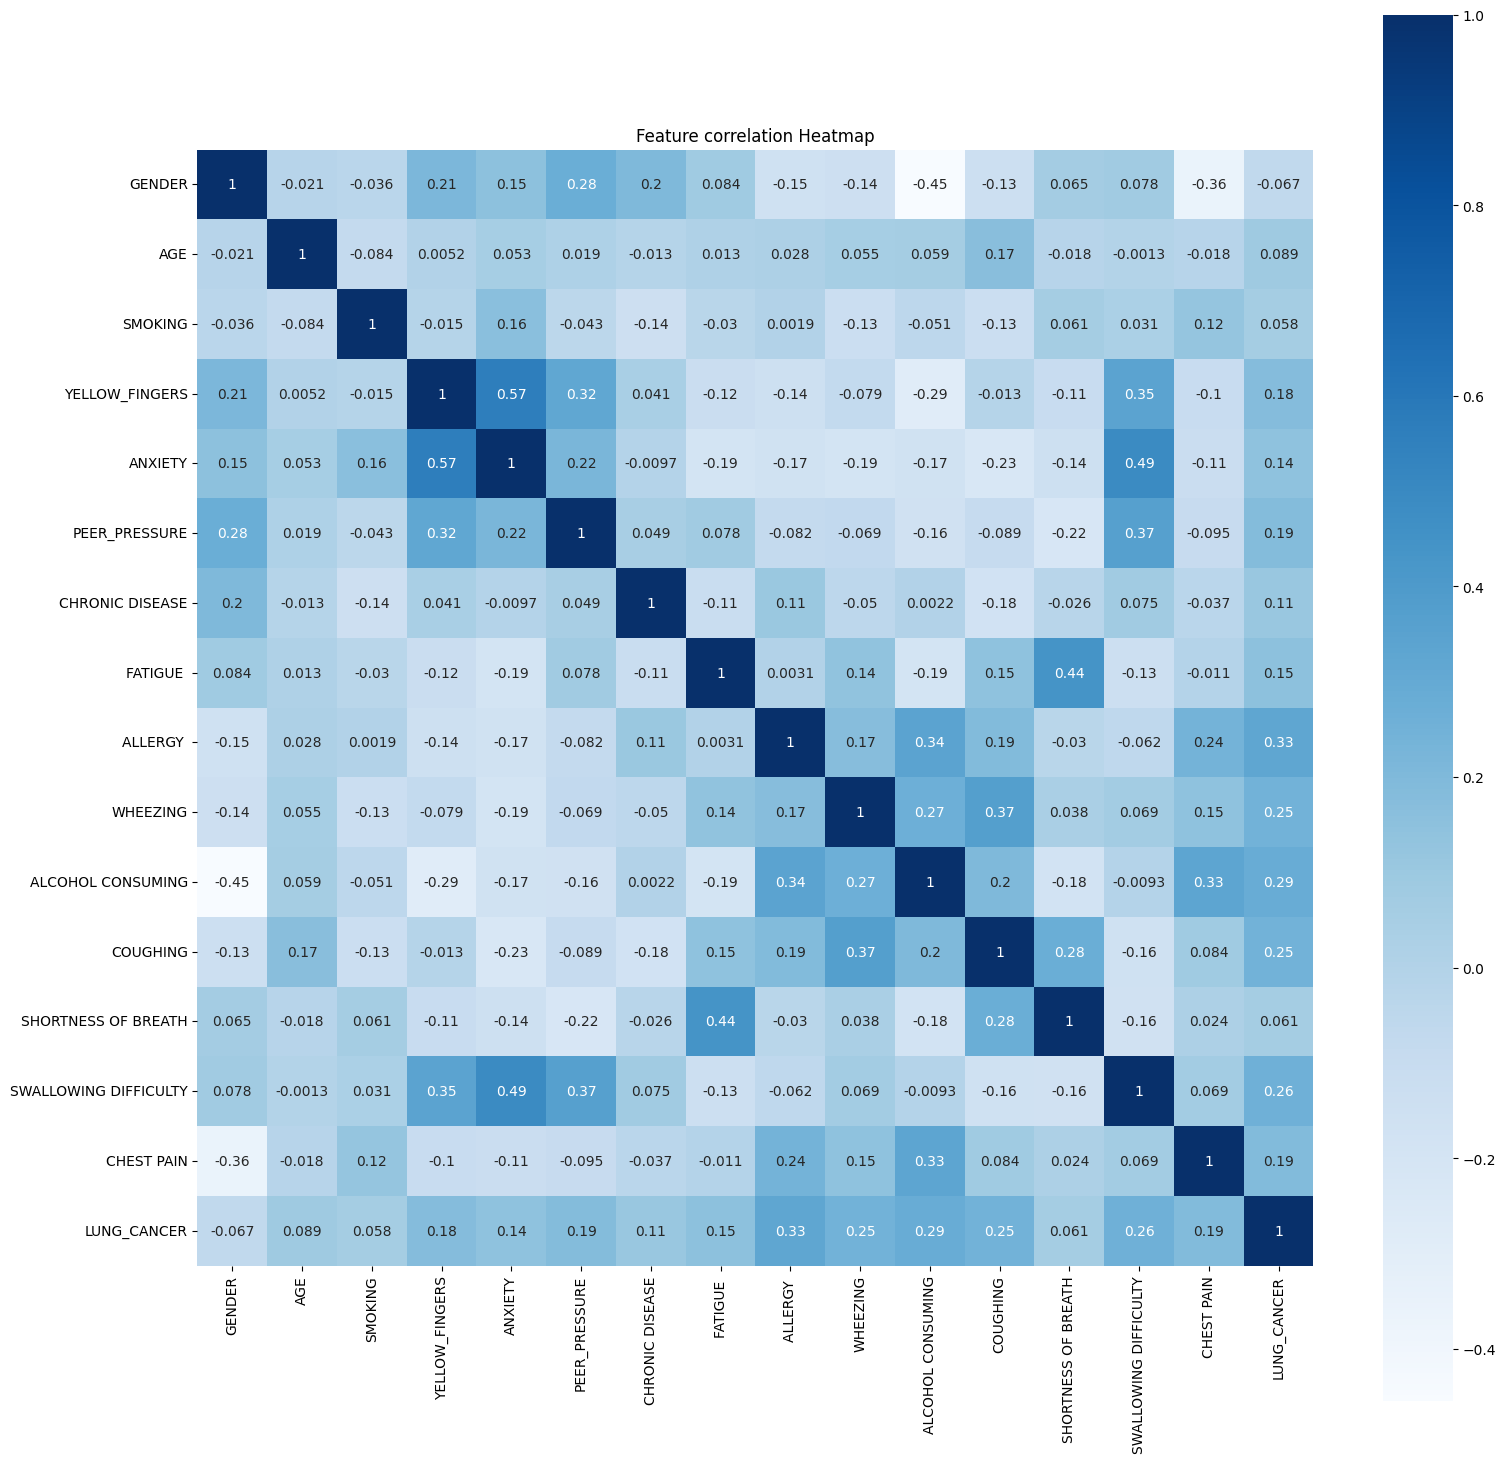

In [ ]:
#Correlation Heatmap
correlation = lung_data.corr()
plt.figure(figsize=(18,18))
sns.heatmap(correlation, cmap="Blues", annot=True, square=True)
plt.title("Feature correlation Heatmap")
plt.show()

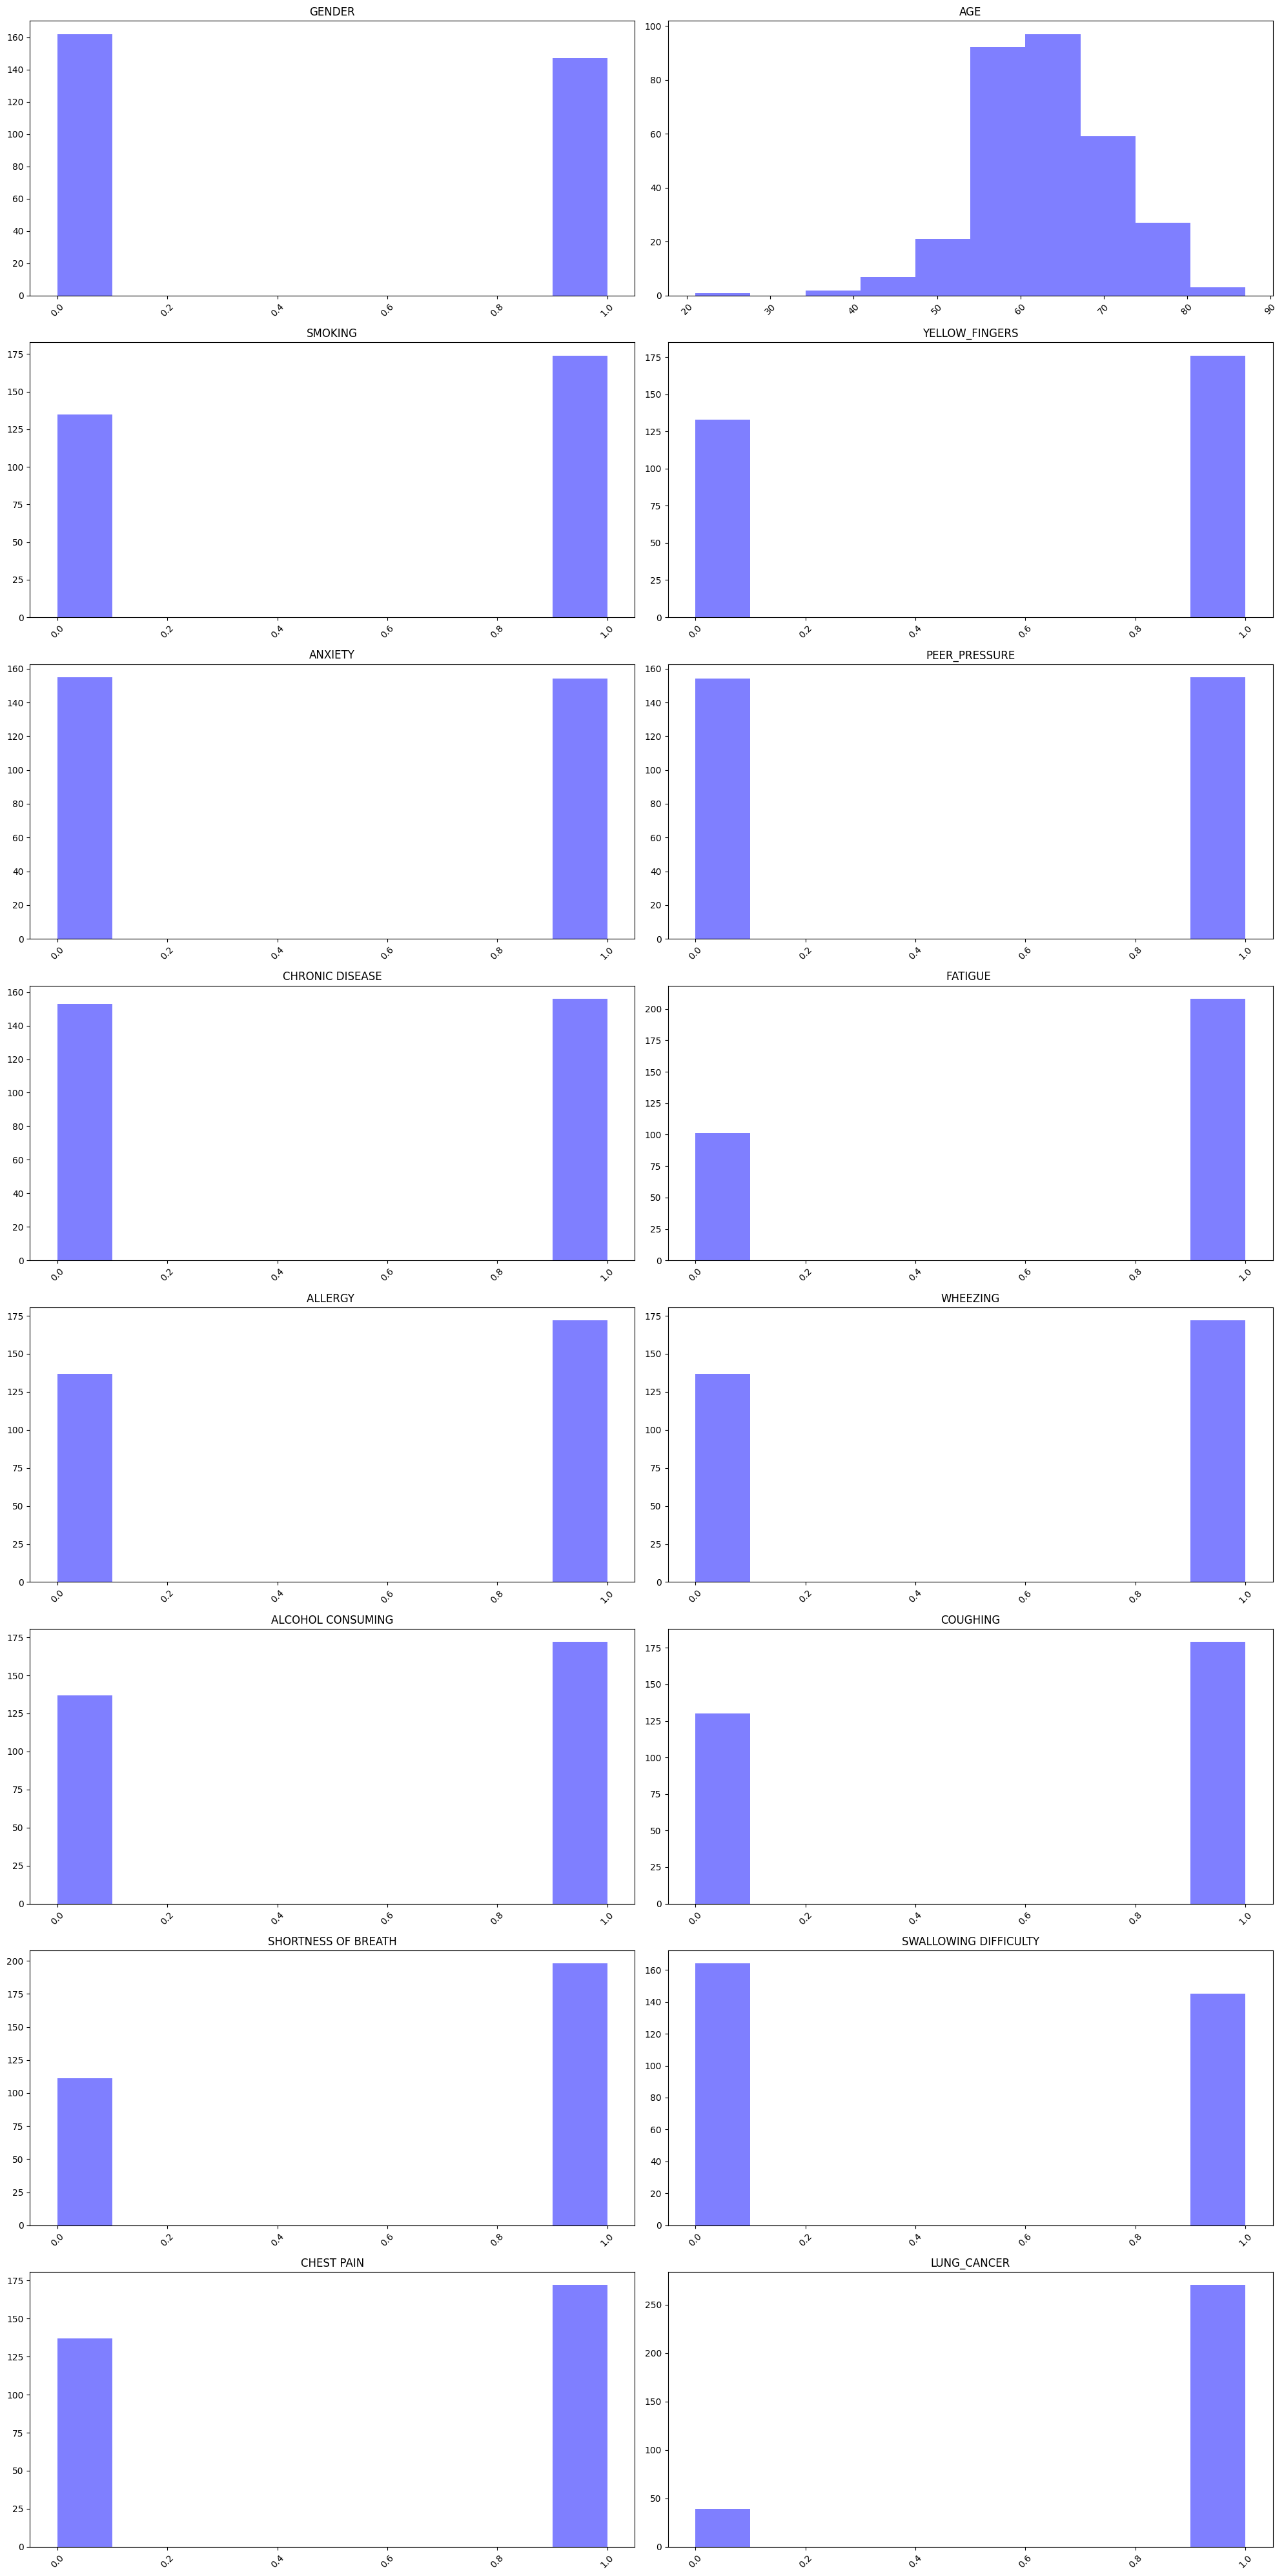

In [ ]:
#Feature Distribution
num_list = list(lung_data.columns)
rows = (len(num_list) // 2) + (len(num_list) % 2)

plt.figure(figsize=(20,40))
for i in range(len(num_list)):
  plt.subplot(rows, 2, i + 1)
  plt.title(num_list[i])
  plt.xticks(rotation=45)
  plt.hist(lung_data[num_list[i]], color='blue', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def plot_roc_curve(models, x_test, y_test):

  plt.figure(figsize=(8,6))

  for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

  plt.plot([0,1],[0,1], 'k--', label='Random Guess')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve for Multiple Models')
  plt.legend(loc='lower right')
  plt.show()

models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Decision Tree": tree,
    "SVM": svm,
    "Naive Bayes": nb,
    "Random Forest": rf_classifier
}



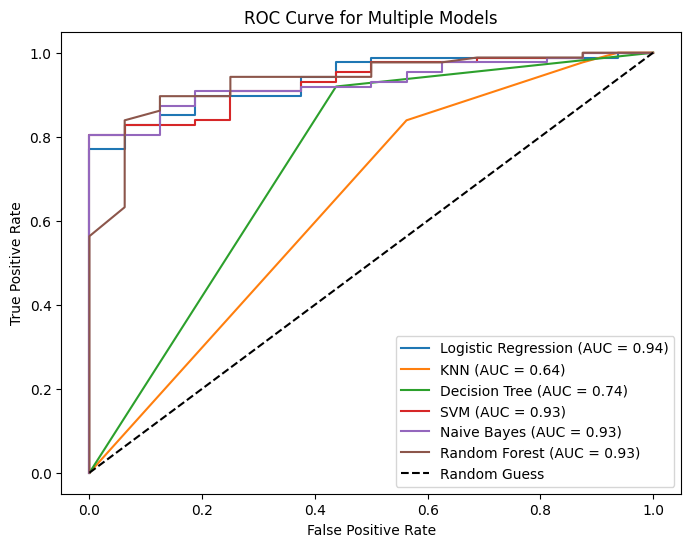

In [ ]:
plot_roc_curve(models, x_test , y_test)


In [ ]:
import joblib
import json

joblib.dump(log_reg, "log_reg.joblib")
joblib.dump(knn, "knn.joblib")
joblib.dump(tree, "decision_tree.joblib")
joblib.dump(svm, "svm.joblib")
joblib.dump(nb, "naive_bayes.joblib")
joblib.dump(rf_classifier, "random_forest.joblib")

metrics = {
    "Logistic Regression": 0.9029,
    "KNN": 0.8447,
    "Decision Tree": 0.8641,
    "SVM": 0.8447,
    "Naive Bayes": 0.8641,
    "Random Forest": 0.8932
}
with open("model_metrics.json", "w") as f:
    json.dump(metrics, f)